In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import importlib

if 'oscillator_model' not in os.listdir(): 
    os.chdir('..')

import oscillator_model.oscillator
importlib.reload(oscillator_model.oscillator)
from oscillator_model.oscillator import Oscillator

import oscillator_model.fitting
importlib.reload(oscillator_model.fitting)
from oscillator_model.fitting import *


import oscillator_model.utils
importlib.reload(oscillator_model.utils)
from oscillator_model.utils import *

c:\Users\jleus\UW_Distributed_Modeling_Synch\oscillator_model\fitting.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.optimize import nnls


In [2]:
f_off_pts_an7 = np.array([1e1, 1e2, 1e3, 1e4, 1e5])
L_dBc_pts_an7 = np.array([-95.0, -125.0, -152.0, -165.0, -170.0])
an7_coeffs = fit_oscillator_coeffs_PSD(f_off_pts_an7, L_dBc_pts_an7)

In [3]:
osc_t1 = Oscillator(
    fosc=10e6, 
    fs=20.0, 
    T=10.0, 
    n_periods=10,
    start_period=5, 
    n_captures=1,
    coeffs_lin=an7_coeffs
)

osc_t2 = Oscillator(
    fosc=10e6, 
    fs=2e4, 
    T=0.01,
    n_periods=10,
    start_period=5,
    n_captures=1,
    coeffs_lin=an7_coeffs
)

osc_t3 = Oscillator(
    fosc=10e6,
    fs=2e7, 
    T=1e-5, 
    n_periods=10,
    start_period=5, 
    n_captures=1,
    coeffs_lin=an7_coeffs
)

for name, osc in [('Trial 1', osc_t1), ('Trial 2', osc_t2), ('Trial 3', osc_t3)]:
    print(f"{name}: f_min = {osc.df} Hz, f_ max = {osc.fs/2} Hz, N = {osc.N_total}")

Trial 1: f_min = 0.01 Hz, f_ max = 10.0 Hz, N = 2000
Trial 2: f_min = 10.0 Hz, f_ max = 10000.0 Hz, N = 2000
Trial 3: f_min = 10000.0 Hz, f_ max = 10000000.0 Hz, N = 2000


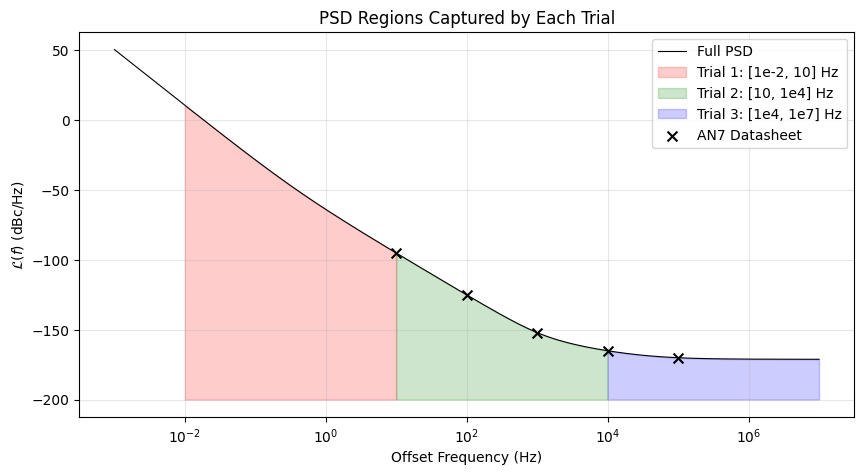

In [4]:
fgrid = np.logspace(-3, 7, 3000)
fgrid, S1_full = osc_t1.S1(fgrid)
L_full = S1_to_dBcHz(S1_full)

plt.figure(figsize=(10, 5))
plt.semilogx(fgrid[1:], L_full[1:], 'k-', lw=0.8, label='Full PSD')

for osc, color, label in [
    (osc_t1, 'red', 'Trial 1: [1e-2, 10] Hz'),
    (osc_t2, 'green', 'Trial 2: [10, 1e4] Hz'),
    (osc_t3, 'blue', 'Trial 3: [1e4, 1e7] Hz')
]:
    fmin = osc.df
    fmax = osc.fs / 2
    mask = (fgrid >= fmin) & (fgrid <= fmax)
    plt.fill_between(fgrid[mask], -200, L_full[mask], alpha=0.2, color=color, label=label)

plt.scatter(f_off_pts_an7, L_dBc_pts_an7, marker='x', color='k', s=50, zorder=5, label='AN7 Datasheet')

plt.xlabel('Offset Frequency (Hz)')
plt.ylabel(r'$\mathcal{L}(f)$ (dBc/Hz)')
plt.title('PSD Regions Captured by Each Trial')
plt.legend()
plt.grid(True, which='both', alpha=0.3)


In [5]:
osc_t1.realize_phase_error()
osc_t2.realize_phase_error()
osc_t3.realize_phase_error()

for name, osc in [('Trial 1', osc_t1), ('Trial 2', osc_t2), ('Trial 3', osc_t3)]:
    result = osc.variance_check()
    print(f"{name}  f=[{osc.df:.1e}, {osc.fs/2:.1e}] Hz")
    print(f"Expected variance: {result['expected']:.4e}")
    print(f"Realized variance: {result['realized']:.4e}")
    print(f"Relative error: {result['rel_error_pct']:.2f} %")


Trial 1  f=[1.0e-02, 1.0e+01] Hz
Expected variance: 2.6273e-01
Realized variance: 2.6273e-01
Relative error: 0.00 %
Trial 2  f=[1.0e+01, 1.0e+04] Hz
Expected variance: 7.5854e-09
Realized variance: 7.5854e-09
Relative error: 0.00 %
Trial 3  f=[1.0e+04, 1.0e+07] Hz
Expected variance: 1.5783e-10
Realized variance: 1.5780e-10
Relative error: 0.02 %


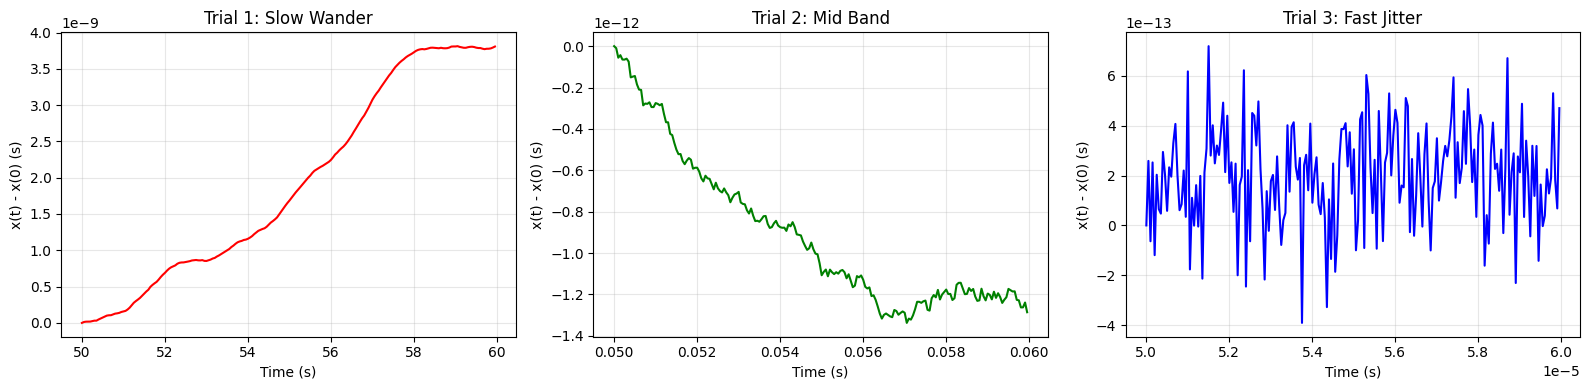

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

for i, (name, osc, color) in enumerate([
    ('Trial 1: Slow Wander', osc_t1, 'red'),
    ('Trial 2: Mid Band', osc_t2, 'green'),
    ('Trial 3: Fast Jitter', osc_t3, 'blue')]):
    x_t = osc.time_fluctuation(osc.phi_out)
    axs[i].plot(osc.t_out, x_t - x_t[0], color=color)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('x(t) - x(0) (s)')
    axs[i].set_title(name)
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()

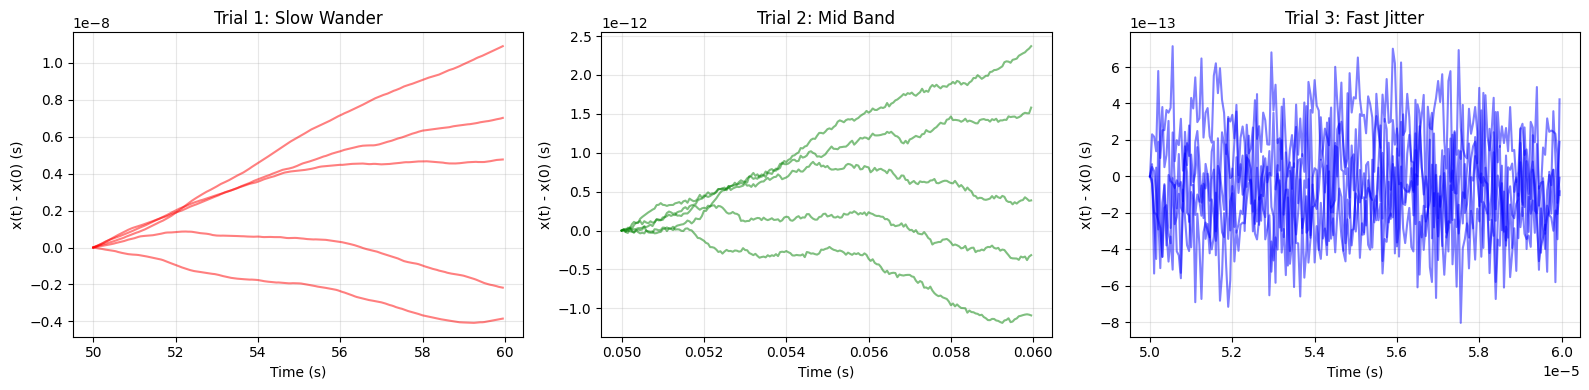

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

for i, (name, osc, color) in enumerate([
    ('Trial 1: Slow Wander', osc_t1, 'red'),
    ('Trial 2: Mid Band', osc_t2, 'green'),
    ('Trial 3: Fast Jitter', osc_t3, 'blue')]):
    for s in range(5):
        osc.update_seed(s)
        osc.realize_phase_error()
        x_t = osc.time_fluctuation(osc.phi_out)
        axs[i].plot(osc.t_out, x_t - x_t[0], color=color, alpha=0.5)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('x(t) - x(0) (s)')
    axs[i].set_title(name)
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()